In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = "../data/processed/data_dengue_graficos.csv"

df = pd.read_csv(PATH)
df.head()


,data_inicio_semana,ano,semana_epidemiologica,casos_notificados,nivel_alerta,nivel_alerta_desc
0,2023-12-31,2024,1,94,1,Verde (Baixo)
1,2024-01-07,2024,2,104,4,Vermelho (Crítico)
2,2024-01-14,2024,3,166,4,Vermelho (Crítico)
3,2024-01-21,2024,4,167,4,Vermelho (Crítico)
4,2024-01-28,2024,5,230,4,Vermelho (Crítico)


    ano  casos_notificados
0  2024               9369
1  2025               4091
2  2026                782


/tmp/ipykernel_43463/2523787909.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


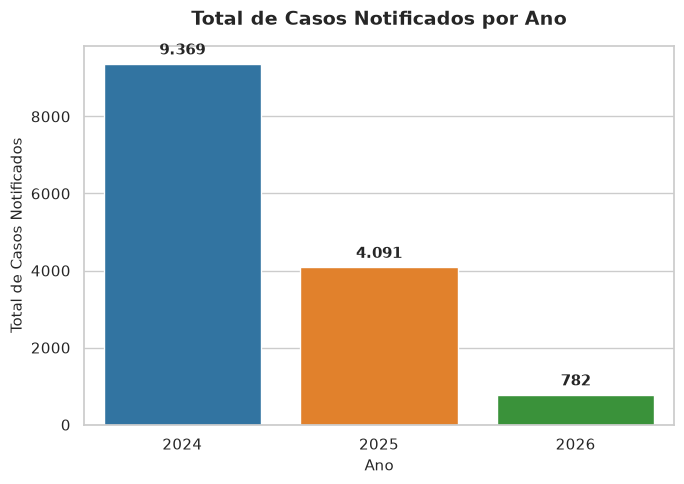

In [18]:
casos_ano = df.groupby("ano", as_index=False)["casos_notificados"].sum()

# Visualização da estrutura da tabela:
print(casos_ano)
#     ano  casos_notificados
# 0  2024               9369
# 1  2025               4091
# 2  2026                782

# 3. Configurar e apresentar o gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

cores = ["#1f77b4", "#ff7f0e", "#2ca02c"]
ax = sns.barplot(
    data=casos_ano,
    x="ano",
    y="casos_notificados",
    palette=cores
)

# 4. Adicionar os valores numéricos no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    if pd.notna(altura) and altura > 0:
        ax.annotate(
            f"{int(altura):,}".replace(",", "."),
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 4),
            textcoords="offset points",
        )

plt.title("Total de Casos Notificados por Ano", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Ano", fontsize=11)
plt.ylabel("Total de Casos Notificados", fontsize=11)
plt.tight_layout()
plt.show()

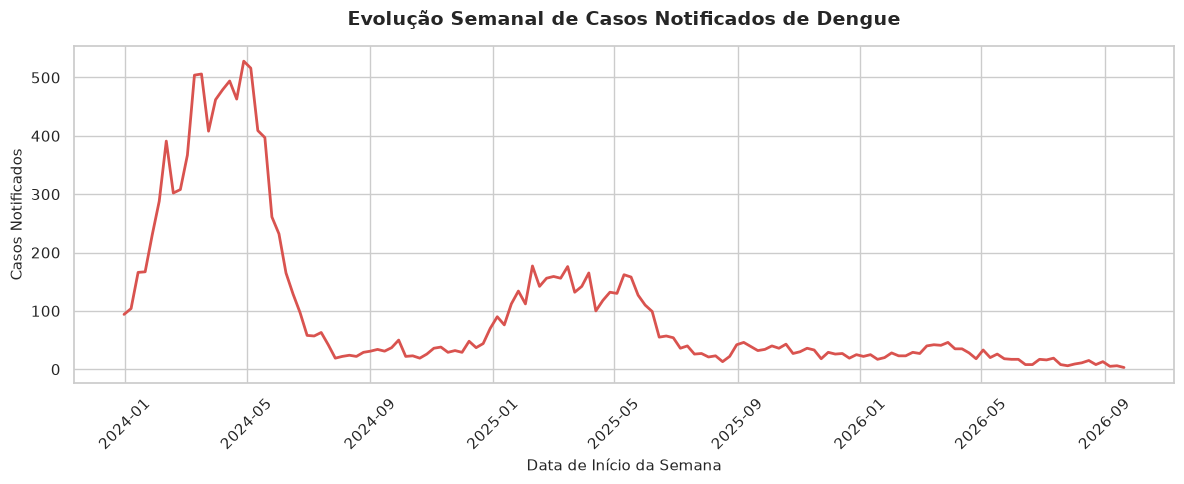

In [19]:
df["data_inicio_semana"] = pd.to_datetime(df["data_inicio_semana"])

# Configuração global de estilo
sns.set_theme(style="whitegrid")

# ==============================================================================
# Gráfico 1: Evolução Semanal Contínua (Série Temporal)
# ==============================================================================
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df,
    x="data_inicio_semana",
    y="casos_notificados",
    color="#d9534f",
    linewidth=2,
)
plt.title(
    "Evolução Semanal de Casos Notificados de Dengue",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Data de Início da Semana", fontsize=11)
plt.ylabel("Casos Notificados", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

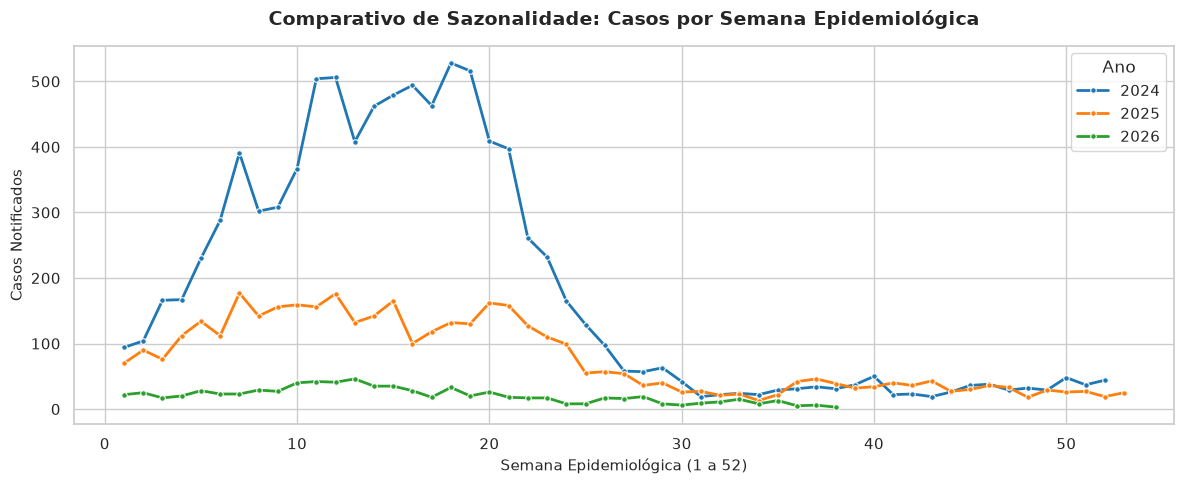

In [20]:
plt.figure(figsize=(12, 5))
cores_anos = {2024: "#1f77b4", 2025: "#ff7f0e", 2026: "#2ca02c"}

sns.lineplot(
    data=df,
    x="semana_epidemiologica",
    y="casos_notificados",
    hue="ano",
    palette=cores_anos,
    marker="o",
    markersize=4,
    linewidth=2,
)
plt.title(
    "Comparativo de Sazonalidade: Casos por Semana Epidemiológica",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Semana Epidemiológica (1 a 52)", fontsize=11)
plt.ylabel("Casos Notificados", fontsize=11)
plt.legend(title="Ano", frameon=True)
plt.tight_layout()
plt.show()

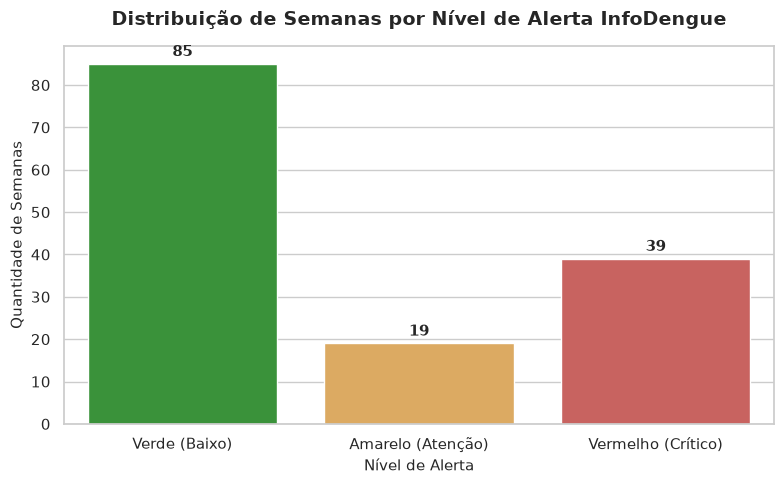

In [21]:
plt.figure(figsize=(8, 5))

# Ordem epidemiológica esperada e paleta semântica
ordem_niveis = [
    "Verde (Baixo)",
    "Amarelo (Atenção)",
    "Laranja (Alerta)",
    "Vermelho (Crítico)",
]
ordem_presente = [
    n for n in ordem_niveis if n in df["nivel_alerta_desc"].unique()
]
cores_alerta = {
    "Verde (Baixo)": "#2ca02c",
    "Amarelo (Atenção)": "#f0ad4e",
    "Laranja (Alerta)": "#ff7f0e",
    "Vermelho (Crítico)": "#d9534f",
}

ax = sns.countplot(
    data=df,
    x="nivel_alerta_desc",
    order=ordem_presente,
    palette=cores_alerta,
    hue="nivel_alerta_desc",
    legend=False,
)

# Adicionar o total numérico em cima de cada barra
for p in ax.patches:
    altura = int(p.get_height())
    if altura > 0:
        ax.annotate(
            f"{altura}",
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.title(
    "Distribuição de Semanas por Nível de Alerta InfoDengue",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Nível de Alerta", fontsize=11)
plt.ylabel("Quantidade de Semanas", fontsize=11)
plt.tight_layout()
plt.show()
